# Final Project MGMT 388: Predictive Analysis

**Team Members:**

1.   Niharika Rai - rai55@purdue.edu
2.   Jared Richardson - jrichars@purdue.edu



**Link to the dataset:** https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

I loaded the dataset and performed basic EDA and checked for missing values. Furthermore, I specifically chose this real world dataset from the UCI Machine Learning Repository because it is highly relevant in today's times as various energy companies look to reduce their electrical energy consumption and shift to more green energy alternatives in an effort to reduce harmful emissions and conserve the environment. Secondly, the dataset contains multivariate characteristics and is perfect for regression tasks. The columns are real data collected over a span of 6 years when the power plant to set to work with full load. This enriches the authenticity of data and helps use machine learning models to solve real world problems related to the environment and achieve the Sustainable Development Goals (SDG) such as affordable and clean energy, industry, innovation and infrastructure, sustainable cities and communities, responsible consumption and production and most importantly, climate action.

In [5]:
df = pd.read_excel("Combined Cycle Power Plant.xlsx")
df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [7]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


The code below suggests that no missing values were detected. Therefore, no rows needed to be dropped.

In [8]:
df.isnull().sum().sum()

np.int64(0)

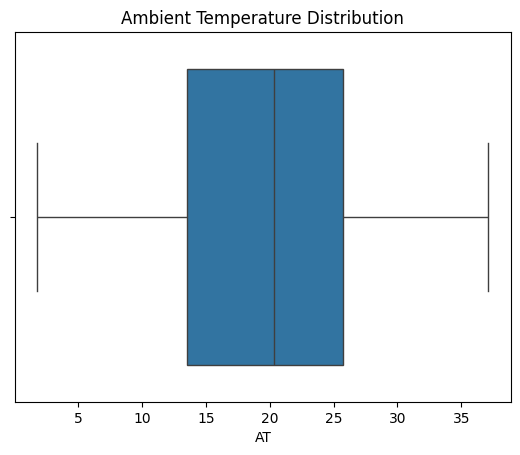

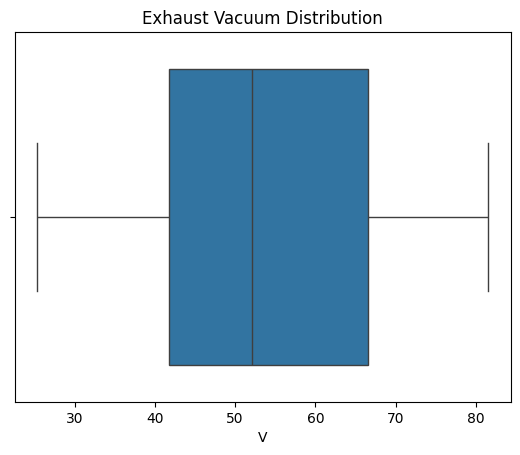

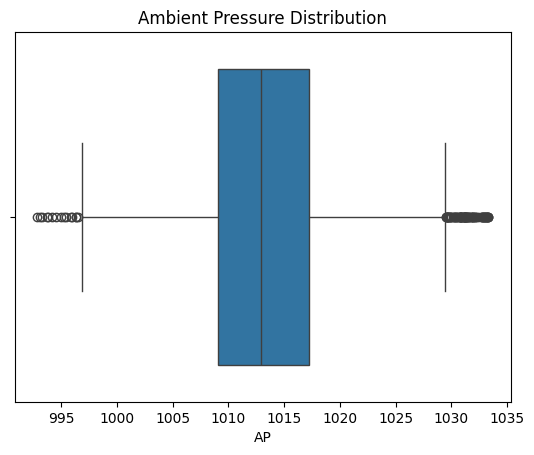

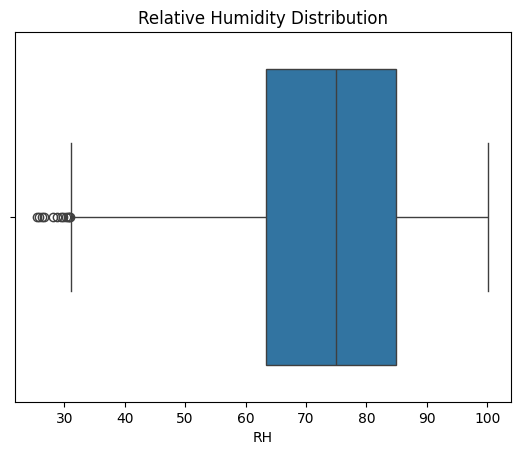

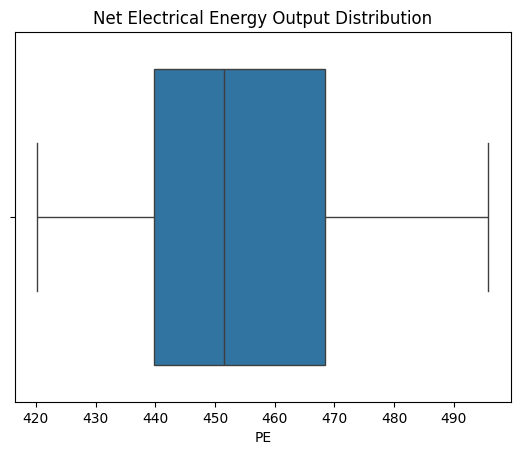

In [9]:
# Box Plots

# Ambient Temperature
plt.figure()
sns.boxplot(x=df["AT"])
plt.title("Ambient Temperature Distribution")

# Exhaust Vacuum
plt.figure()
sns.boxplot(x=df["V"])
plt.title("Exhaust Vacuum Distribution")

# Ambient Pressure
plt.figure()
sns.boxplot(x=df["AP"])
plt.title("Ambient Pressure Distribution")

# Relative Humidity
plt.figure()
sns.boxplot(x=df["RH"])
plt.title("Relative Humidity Distribution")

# Net Electrical Energy Output
plt.figure()
sns.boxplot(x=df["PE"])
plt.title("Net Electrical Energy Output Distribution")

plt.show()

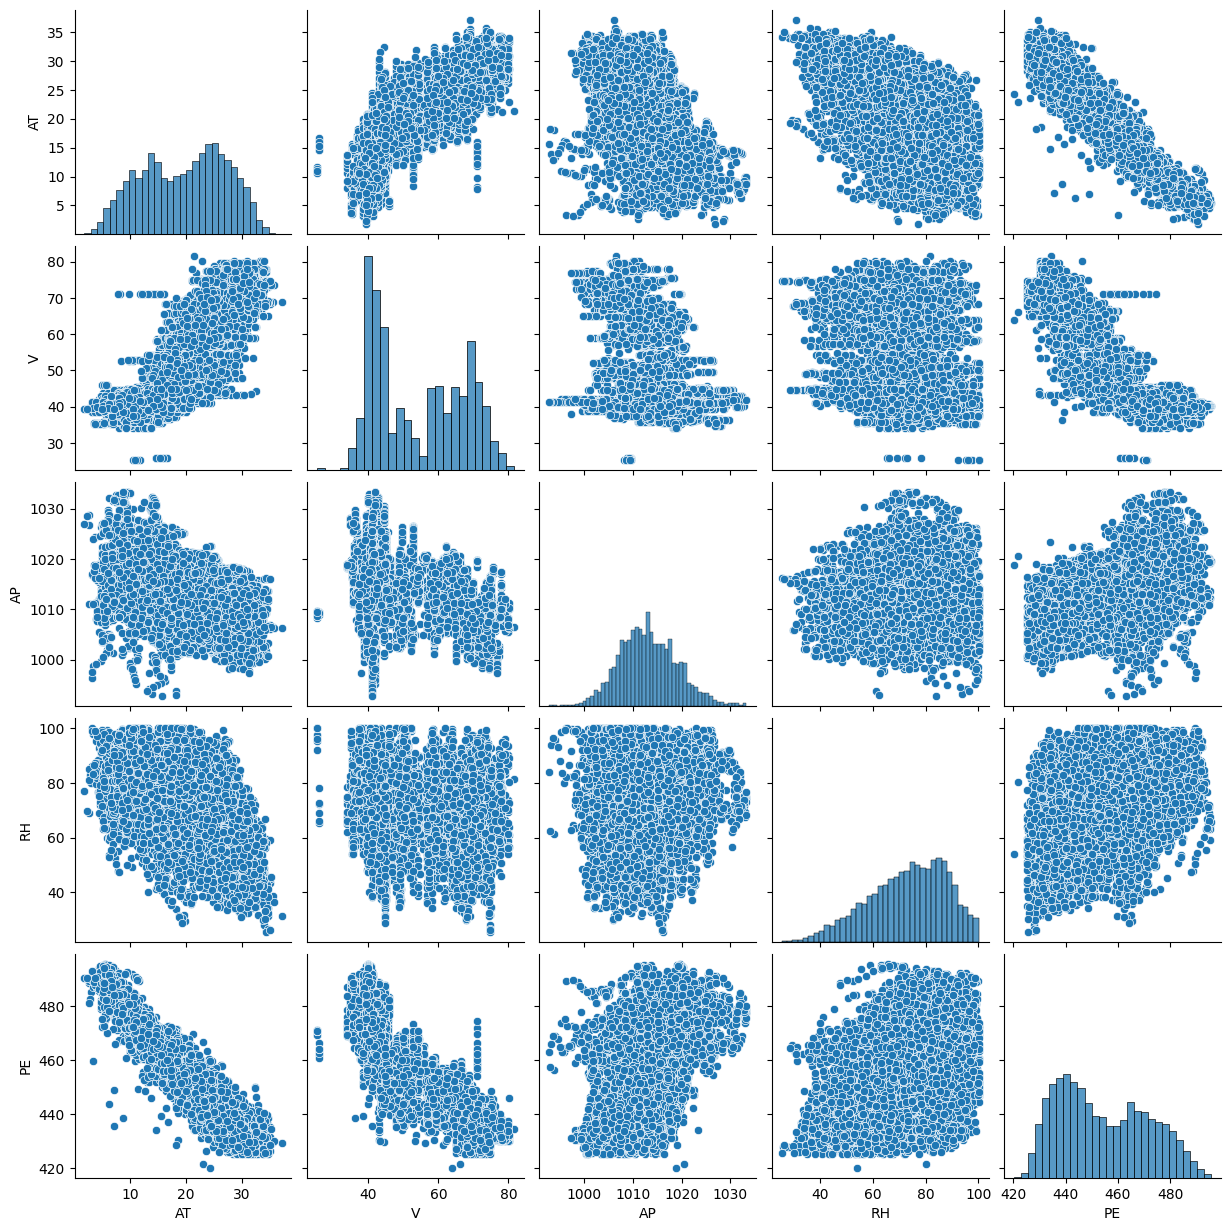

In [10]:
# Pairplot
sns.pairplot(df)
plt.show()

We created a pariplot for all of the features in the dataset with histograms down the middle for more information. AT, V, PE appear to have bimodal distributions while AP looks normally distributed. From its histogram, RH seems to be fairly left skewed.

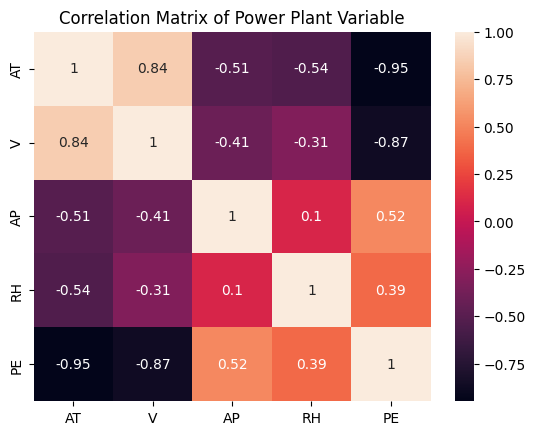

In [11]:
# correlation matrix
cm = df.corr()
cm
sns.heatmap(cm, annot = True)
plt.title("Correlation Matrix of Power Plant Variable")
plt.show()

It looks like the strongest between correlations for PE are negative with AT, and V while the strongest positive correlation seems to be AP.

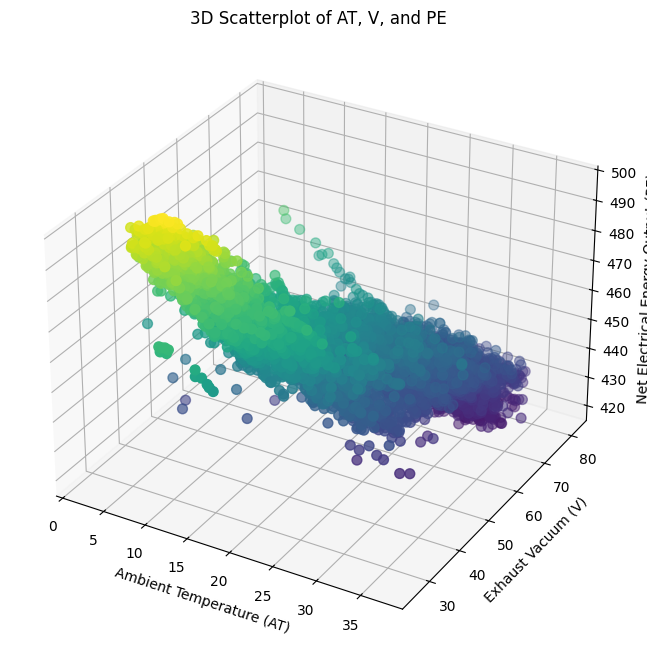

In [12]:
# 3d scatterplot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['AT'], df['V'], df['PE'], c=df['PE'], cmap='viridis', s=50)

ax.set_xlabel('Ambient Temperature (AT)')
ax.set_ylabel('Exhaust Vacuum (V)')
ax.set_zlabel('Net Electrical Energy Output (PE)')
ax.set_title('3D Scatterplot of AT, V, and PE')

plt.show()

The box plots above showed that there were outliers in the dataset. So, I wrote a function and used the IQR method to remove the outliers. This filtered the dataset and returned a new df, free of outliers.

In [13]:
# remove outliers using IQR method
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

remove_outliers(df, df.columns)

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


Since all the variables had different units, I standardized the entire dataset and calculated their z-scores for effective analysis.

In [14]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
scaled_df = sc.fit_transform(df)
scaled_df

array([[-0.62951938, -0.98729659,  1.8204884 , -0.00951935,  0.52120807],
       [ 0.74190911,  0.68104512,  1.1418628 , -0.97462052, -0.58566442],
       [-1.95129733, -1.17301765, -0.18507756,  1.2898397 ,  2.00367889],
       ...,
       [ 1.56583973,  1.57581141, -0.05709854, -2.52261812, -1.45288056],
       [ 0.64797565,  1.19177803,  0.1011913 , -0.74790051, -1.09134518],
       [ 0.26150656,  0.64641916,  0.66867722, -0.37254534, -0.06357687]])

The code below shows that I separated the predictor variables as X and the target variable as y for regression analysis.

In [15]:
X = scaled_df[:, :-1]
y = scaled_df[:, -1]

In [16]:
X

array([[-0.62951938, -0.98729659,  1.8204884 , -0.00951935],
       [ 0.74190911,  0.68104512,  1.1418628 , -0.97462052],
       [-1.95129733, -1.17301765, -0.18507756,  1.2898397 ],
       ...,
       [ 1.56583973,  1.57581141, -0.05709854, -2.52261812],
       [ 0.64797565,  1.19177803,  0.1011913 , -0.74790051],
       [ 0.26150656,  0.64641916,  0.66867722, -0.37254534]])

In [17]:
y

array([ 0.52120807, -0.58566442,  2.00367889, ..., -1.45288056,
       -1.09134518, -0.06357687])

I first split the X and y into testing and training sets. Here, 80% of the data was used for training the model and 20% of the data was used for testing the model.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

After spliting the X and y into training and testing sets, I implemented a variety of regression models such as Linear Regression, Polynomial Regression, Decision Tree Regression and Random Forest Regression to train the training set. After training the training set, I applied the various models on the testing set to find the predicted values of the target variable. Below is the code for Linear Regression.

In [19]:
from sklearn.linear_model import LinearRegression

regressor_lr = LinearRegression()
regressor_lr.fit(X_train, y_train)

LinearRegression()

Below is the variable that stores the predicted values of y using the X testing set, with the Linear Regression Model.  

In [20]:
y_pred_lr = regressor_lr.predict(X_test)

Below is the code for training the model using Polynomial Regression. I went further and experimented with Polynomial Regression by changing the degrees to 2, 4 and 6. I did this in an effort to create more accurate regression models that can be used to predict the target variable.

In [21]:
from sklearn.preprocessing import PolynomialFeatures

poly2 = PolynomialFeatures(degree = 2)
X_train_poly_2 = poly2.fit_transform(X_train)
X_test_poly_2 = poly2.fit_transform(X_test)
regressor_pr_2 = LinearRegression()
regressor_pr_2.fit(X_train_poly_2, y_train)

LinearRegression()

In [22]:
poly4 = PolynomialFeatures(degree = 4)
X_train_poly_4 = poly4.fit_transform(X_train)
X_test_poly_4 = poly4.fit_transform(X_test)
regressor_pr_4 = LinearRegression()
regressor_pr_4.fit(X_train_poly_4, y_train)

LinearRegression()

In [23]:
poly6 = PolynomialFeatures(degree = 6)
X_train_poly_6 = poly6.fit_transform(X_train)
X_test_poly_6 = poly6.fit_transform(X_test)
regressor_pr_6 = LinearRegression()
regressor_pr_6.fit(X_train_poly_6, y_train)

LinearRegression()

Below are the variables that store the predicted values of y using the X testing set, with the Polynomial Regression Model where degrees equal 2, 4 and 6.  

In [24]:
y_pred_pr_2 = regressor_pr_2.predict(X_test_poly_2)
y_pred_pr_4 = regressor_pr_4.predict(X_test_poly_4)
y_pred_pr_6 = regressor_pr_6.predict(X_test_poly_6)

Below is the code for training the model using Decision Tree Regression.  

In [25]:
from sklearn.tree import DecisionTreeRegressor

regressor_dt = DecisionTreeRegressor(random_state = 0)
regressor_dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

Below is the variable that stores the predicted values of y using the X testing set, with Decision Tree Regression.

In [26]:
y_pred_dt = regressor_dt.predict(X_test)

Below is the code for training the model using Random Forest Regression.

In [27]:
from sklearn.ensemble import RandomForestRegressor

regressor_rf = RandomForestRegressor(random_state = 0)
regressor_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

Below is the variable that stores the predicted values of y using the X testing set, with Random Forest Regression.

In [28]:
y_pred_rf = regressor_rf.predict(X_test)

To evaluate the various regression models, I computed their Mean Squared Error and R2 scores. A low Mean Squared Error value and a high R2 score indicates strong predictability of the regression model, making it a perfect fit for the real-world dataset.

In [29]:
from sklearn.metrics import mean_squared_error, r2_score

mean_squared_error_lr = mean_squared_error(y_test, y_pred_lr)
mean_squared_error_pr_2 = mean_squared_error(y_test, y_pred_pr_2)
mean_squared_error_pr_4 = mean_squared_error(y_test, y_pred_pr_4)
mean_squared_error_pr_6 = mean_squared_error(y_test, y_pred_pr_6)
mean_squared_error_dt = mean_squared_error(y_test, y_pred_dt)
mean_squared_error_rf = mean_squared_error(y_test, y_pred_rf)

r2_score_lr = r2_score(y_test, y_pred_lr)
r2_score_pr_2 = r2_score(y_test, y_pred_pr_2)
r2_score_pr_4 = r2_score(y_test, y_pred_pr_4)
r2_score_pr_6 = r2_score(y_test, y_pred_pr_6)
r2_score_dt = r2_score(y_test, y_pred_dt)
r2_score_rf = r2_score(y_test, y_pred_rf)

From the outputs below, we can see that Random Forest Regression has the lowest Mean Squared Error and the highest R2 indicating that it most accurately predict the target variable.  

In [30]:
print(f'Mean Squared Error for Linear Regression: {mean_squared_error_lr}')
print(f'Mean Squared Error for Polynomial Regression (degree 2): {mean_squared_error_pr_2}')
print(f'Mean Squared Error for Polynomial Regression (degree 4): {mean_squared_error_pr_4}')
print(f'Mean Squared Error for Polynomial Regression (degree 6): {mean_squared_error_pr_6}')
print(f'Mean Squared Error for Decision Tree Regression: {mean_squared_error_dt}')
print(f'Mean Squared Error for Random Forest Regression: {mean_squared_error_rf}')

Mean Squared Error for Linear Regression: 0.06775475456682463
Mean Squared Error for Polynomial Regression (degree 2): 0.05807664749441435
Mean Squared Error for Polynomial Regression (degree 4): 0.05432552035199495
Mean Squared Error for Polynomial Regression (degree 6): 0.05103239205257819
Mean Squared Error for Decision Tree Regression: 0.0757436197419307
Mean Squared Error for Random Forest Regression: 0.03494199018996695


In [31]:
print(f'R2 score for Linear Regression: {r2_score_lr}')
print(f'R2 score for Polynomial Regression (degree 2): {r2_score_pr_2}')
print(f'R2 score for Polynomial Regression (degree 4): {r2_score_pr_4}')
print(f'R2 score for Polynomial Regression (degree 6): {r2_score_pr_6}')
print(f'R2 score for Decision Tree Regression: {r2_score_dt}')
print(f'R2 score for Random Forest Regression: {r2_score_rf}')

R2 score for Linear Regression: 0.9325315554761302
R2 score for Polynomial Regression (degree 2): 0.942168765946238
R2 score for Polynomial Regression (degree 4): 0.9459040420184242
R2 score for Polynomial Regression (degree 6): 0.9491832546050487
R2 score for Decision Tree Regression: 0.9245764487043432
R2 score for Random Forest Regression: 0.9652056635470465


Below are the data visualizations for the various regression models that show the actual and predicted values with a trendline. Although the graphs look the same, there are suble differences in how the data points are scattered. For example, Linear Regression Model graph (1st graph) shows that the actual and predicted values are scattered apart. However, the Random Forest Regression Model graph (last graph) shows that the actual and predicted values are scattered more closely. This observation justfies the reasonings for a low Mean Squared Value and high R2 value, indicating that the Random Forest Regression Model is best suited for our chosen real world dataset.

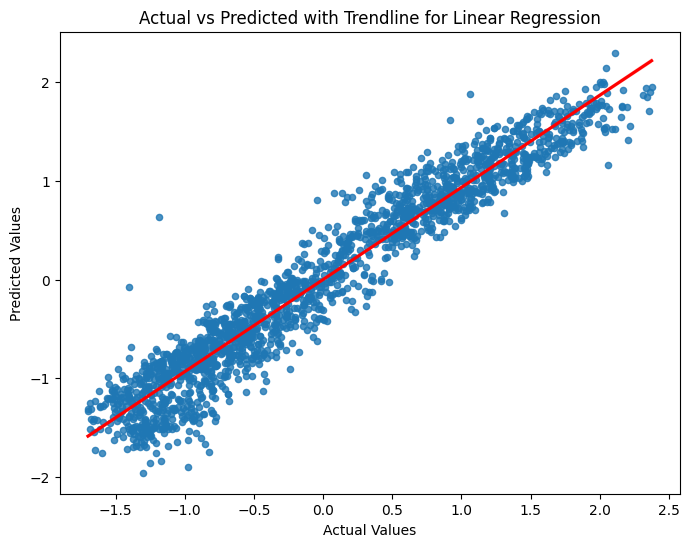

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=y_pred_lr, scatter_kws={"s": 20}, line_kws={"color":"red"})

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted with Trendline for Linear Regression')
plt.show()

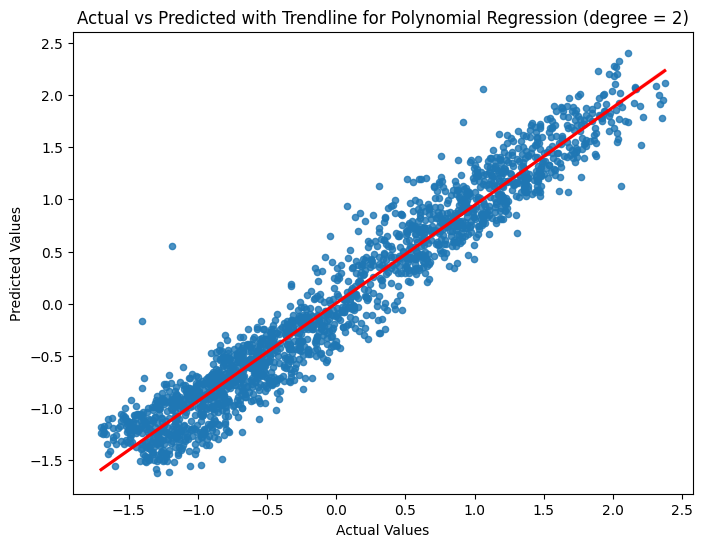

In [33]:
plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=y_pred_pr_2, scatter_kws={"s": 20}, line_kws={"color":"red"})

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted with Trendline for Polynomial Regression (degree = 2)')
plt.show()

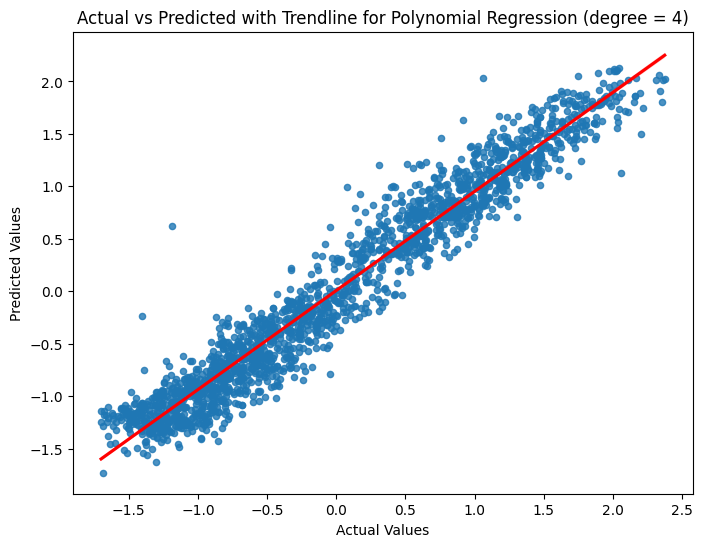

In [34]:
plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=y_pred_pr_4, scatter_kws={"s": 20}, line_kws={"color":"red"})

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted with Trendline for Polynomial Regression (degree = 4)')
plt.show()

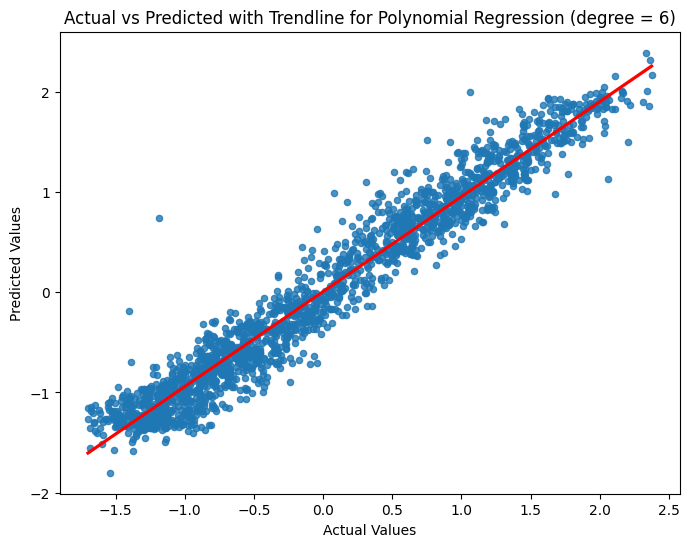

In [35]:
plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=y_pred_pr_6, scatter_kws={"s": 20}, line_kws={"color":"red"})

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted with Trendline for Polynomial Regression (degree = 6)')
plt.show()

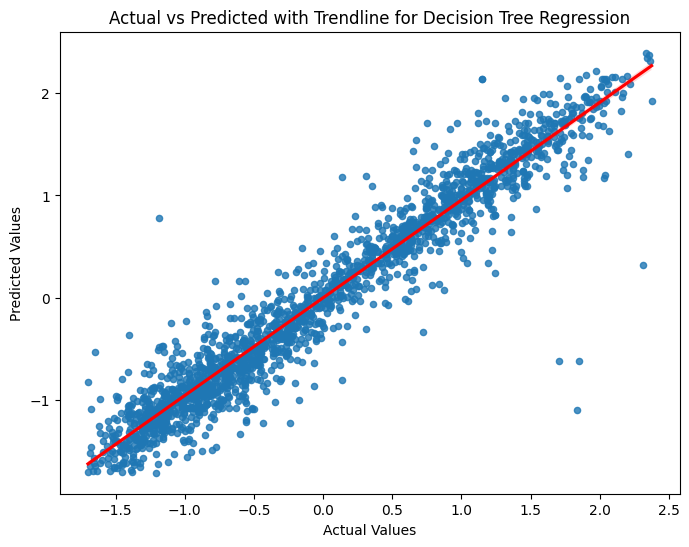

In [36]:
plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=y_pred_dt, scatter_kws={"s": 20}, line_kws={"color":"red"})

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted with Trendline for Decision Tree Regression')
plt.show()

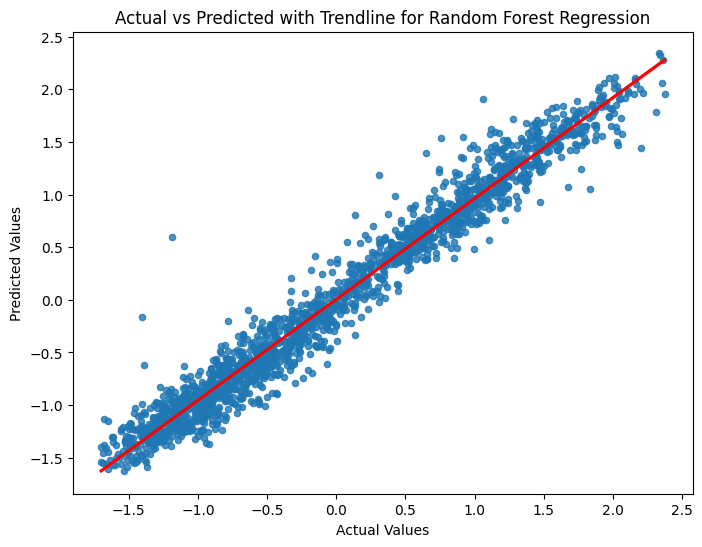

In [37]:
plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=y_pred_rf, scatter_kws={"s": 20}, line_kws={"color":"red"})

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted with Trendline for Random Forest Regression')
plt.show()

In [38]:
from scipy.stats import randint
import random
from sklearn.model_selection import RandomizedSearchCV


param_distributions = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

random_search = RandomizedSearchCV(estimator=regressor_rf, param_distributions=param_distributions, n_iter=20,
                                   cv=5, scoring='r2', random_state=42, verbose=1)
random_search.fit(X_train, y_train)

# Best parameters, score, model.
print("Best parameters from Randomized Search:", random_search.best_params_)
print("Best R2 from Randomized Search:", random_search.best_score_)
print("Best model from Randomized Search:", random_search.best_estimator_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters from Randomized Search: {'max_depth': 31, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 137}
Best R2 from Randomized Search: 0.9585645599199315
Best model from Randomized Search: RandomForestRegressor(max_depth=31, min_samples_split=3, n_estimators=137,
                      random_state=0)


Used Randomized Search cross validation to try different # of estimators, max depth, min samples split, and min sample of leaves. This produced a model that had a worse r2 than before however still gave a great performance. The best combination of hyperparameters was 'max_depth': 31, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 137.

/tmp/ipykernel_2030/1861556357.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


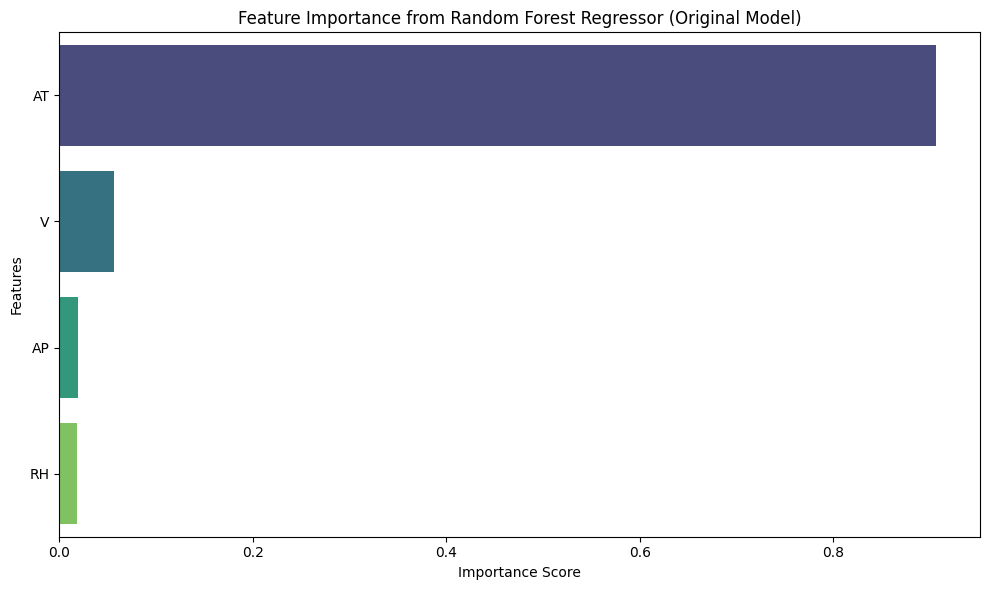

In [39]:
# grab feature importances from the original regressor_rf
importances = regressor_rf.feature_importances_

# match feature names to importances
feature_names = df.iloc[:, :-1].columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# sort features
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# plotting feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance from Random Forest Regressor (Original Model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


It seems the most impactful feature by far and away is AT with a feature importance of over 0.8.

In [40]:
# select only the AT column
X_train_at = X_train[:, [0]]
X_test_at = X_test[:, [0]]

rf_at = RandomForestRegressor(random_state=0)
rf_at.fit(X_train_at, y_train)
y_pred_at = rf_at.predict(X_test_at)

print("R2 (only AT):", r2_score(y_test, y_pred_at))
print("MSE (only AT):", mean_squared_error(y_test, y_pred_at))

R2 (only AT): 0.8904408224434295
MSE (only AT): 0.11002410442799446


We re-evaluated model performance using only the top feature (AT), which had a feature importance > 0.8. While the tuned Random Forest with all features achieved an R² of above 0.9, the model using only AT achieved an R² of only 0.89. This demonstrates that AT alone carries significant predictive power, however the other features are still essential for best model performance. Both of these models however did not recieve an r2 above that of our non-tuned model. The mse for the model only using AT did have a much lower mse than our original model however.